In [2]:
# ------------------------------
#Code for Model 1
# 1. IMPORTS
# ------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix, make_scorer
from xgboost import XGBClassifier

# ------------------------------
# 2. LOAD DATA
# ------------------------------
df = pd.read_csv("icu_mortality_prediction_data_version_1.csv")
target = "long_icu_stay"  # 0/1

# ------------------------------
# 3. TRAIN/VAL/TEST SPLIT
# ------------------------------
X = df.drop(columns=[target])
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
print(f"Target distribution (train):\n{y_train.value_counts()}")

# ------------------------------
# 4. PIPELINE (Handle NaNs + Scaling)
# ------------------------------
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[("prep", preprocessor)])

X_train_processed = pipeline.fit_transform(X_train)
X_val_processed = pipeline.transform(X_val)
X_test_processed = pipeline.transform(X_test)

# ------------------------------
# 5. XGBOOST CLASSIFIER
# ------------------------------
# Automatic handling of class imbalance using scale_pos_weight
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    objective="binary:logistic",
    n_jobs=-1,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# ------------------------------
# 6. HYPERPARAMETER TUNING
# ------------------------------
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 6],
    "learning_rate": [0.05, 0.1, 0.15],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 0.9],
    "gamma": [0, 0.1]
}

# Use F1 score for hyperparameter optimization (positive class = 1)
f1_scorer = make_scorer(f1_score, pos_label=1)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,  # reduce for speed
    cv=3,
    scoring=f1_scorer,  # <-- F1 instead of ROC-AUC
    verbose=1,
    random_state=42
)

random_search.fit(X_train_processed, y_train)
best_xgb = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

# ------------------------------
# 7. FIT BEST MODEL
# ------------------------------
best_xgb.fit(X_train_processed, y_train)

# ------------------------------
# 8. THRESHOLD TUNING (Validation)
# ------------------------------
y_val_probs = best_xgb.predict_proba(X_val_processed)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)
f1_scores = []

for t in thresholds:
    y_val_pred = (y_val_probs >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_val_pred))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
print(f"Best threshold (validation F1): {best_threshold:.2f}, Max F1: {best_f1:.4f}")

# ------------------------------
# 9. EVALUATION FUNCTION
# ------------------------------
def evaluate_model(model, X, y, threshold):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)
    print("F1-score:", f1_score(y, preds))
    print("Accuracy:", (preds == y).mean())
    print(classification_report(y, preds))
    print("Confusion Matrix:\n", confusion_matrix(y, preds))

# ------------------------------
# 10. FINAL EVALUATION
# ------------------------------
print("TRAIN PERFORMANCE")
evaluate_model(best_xgb, X_train_processed, y_train, best_threshold)

print("VALIDATION PERFORMANCE")
evaluate_model(best_xgb, X_val_processed, y_val, best_threshold)

print("TEST PERFORMANCE")
evaluate_model(best_xgb, X_test_processed, y_test, best_threshold)


Train: (17737, 233), Validation: (3801, 233), Test: (3801, 233)
Target distribution (train):
long_icu_stay
0    14787
1     2950
Name: count, dtype: int64
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best CV score: 0.5381517368714328
Best threshold (validation F1): 0.57, Max F1: 0.5564
TRAIN PERFORMANCE
F1-score: 0.7617034128662036
Accuracy: 0.9110334329367988
              precision    recall  f1-score   support

           0       0.97      0.92      0.95     14787
           1       0.69      0.85      0.76      2950

    accuracy                           0.91     17737
   macro avg       0.83      0.89      0.85     17737
weighted avg       0.92      0.91      0.91     17737

Confusion Matrix:
 [[13637  1150]
 [  428  2522]]
VALIDATION PERFORMANCE
F1-score: 0.5564342199856218
Accuracy: 0.8376742962378322
              precision    r

AUC (Train): 0.964
AUC (Validation): 0.837
AUC (Test): 0.848


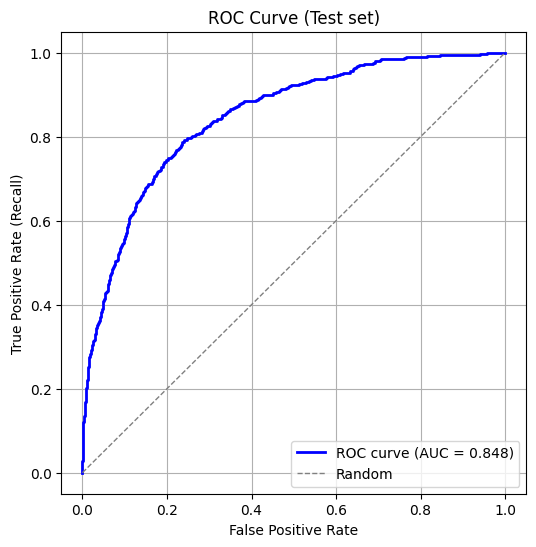

In [4]:
#ROC and AUC for model 1
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
# TRAIN
y_train_probs = best_xgb.predict_proba(X_train_processed)[:, 1]
auc_train = roc_auc_score(y_train, y_train_probs)

# VALIDATION
y_val_probs = best_xgb.predict_proba(X_val_processed)[:, 1]
auc_val = roc_auc_score(y_val, y_val_probs)

# TEST
y_test_probs = best_xgb.predict_proba(X_test_processed)[:, 1]
auc_test = roc_auc_score(y_test, y_test_probs)

print(f"AUC (Train): {auc_train:.3f}")
print(f"AUC (Validation): {auc_val:.3f}")
print(f"AUC (Test): {auc_test:.3f}")



# Test set ROC
y_test_probs = best_xgb.predict_proba(X_test_processed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve (Test set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [5]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# ------------------------------
#  AUPRC CALCULATION for model 1
# ------------------------------

def compute_auprc(y_true, y_prob):
    """Returns the AUPRC and the full precision-recall curve."""
    auprc = average_precision_score(y_true, y_prob)
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    return auprc, precision, recall, thresholds

# TRAIN
auprc_train, prec_train, rec_train, thr_train = compute_auprc(y_train, y_train_probs)

# VALIDATION
auprc_val, prec_val, rec_val, thr_val = compute_auprc(y_val, y_val_probs)

# TEST
auprc_test, prec_test, rec_test, thr_test = compute_auprc(y_test, y_test_probs)

print(f"AUPRC (Train): {auprc_train:.3f}")
print(f"AUPRC (Validation): {auprc_val:.3f}")
print(f"AUPRC (Test): {auprc_test:.3f}")


AUPRC (Train): 0.872
AUPRC (Validation): 0.567
AUPRC (Test): 0.584


In [6]:
#Code for Model 2
# ------------------------------
# 1. IMPORTS
# ------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix, make_scorer
from xgboost import XGBClassifier

# ------------------------------
# 2. LOAD DATA
# ------------------------------
df = pd.read_csv("icu_mortality_prediction_data_version_2.csv")
target = "long_icu_stay"  # 0/1

# ------------------------------
# 3. TRAIN/VAL/TEST SPLIT
# ------------------------------
X = df.drop(columns=[target])
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
print(f"Target distribution (train):\n{y_train.value_counts()}")

# ------------------------------
# 4. PIPELINE (Handle NaNs + Scaling)
# ------------------------------
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[("prep", preprocessor)])

X_train_processed = pipeline.fit_transform(X_train)
X_val_processed = pipeline.transform(X_val)
X_test_processed = pipeline.transform(X_test)

# ------------------------------
# 5. XGBOOST CLASSIFIER
# ------------------------------
# Automatic handling of class imbalance using scale_pos_weight
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    objective="binary:logistic",
    n_jobs=-1,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# ------------------------------
# 6. HYPERPARAMETER TUNING
# ------------------------------
param_grid = {
    "n_estimators": [100, 200, 300,400,500],
    "max_depth": [3, 5, 6],
    "learning_rate": [0.05, 0.1, 0.15],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 0.9],
    "gamma": [0, 0.1]
}

# Use F1 score for hyperparameter optimization (positive class = 1)
f1_scorer = make_scorer(f1_score, pos_label=1)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,  # reduce for speed
    cv=3,
    scoring=f1_scorer,  # <-- F1 instead of ROC-AUC
    verbose=1,
    random_state=42
)

random_search.fit(X_train_processed, y_train)
best_xgb = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

# ------------------------------
# 7. FIT BEST MODEL
# ------------------------------
best_xgb.fit(X_train_processed, y_train)

# ------------------------------
# 8. THRESHOLD TUNING (Validation)
# ------------------------------
y_val_probs = best_xgb.predict_proba(X_val_processed)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)
f1_scores = []

for t in thresholds:
    y_val_pred = (y_val_probs >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_val_pred))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
print(f"Best threshold (validation F1): {best_threshold:.2f}, Max F1: {best_f1:.4f}")

# ------------------------------
# 9. EVALUATION FUNCTION
# ------------------------------
def evaluate_model(model, X, y, threshold):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)
    print("F1-score:", f1_score(y, preds))
    print("Accuracy:", (preds == y).mean())
    print(classification_report(y, preds))
    print("Confusion Matrix:\n", confusion_matrix(y, preds))

# ------------------------------
# 10. FINAL EVALUATION
# ------------------------------
print("TRAIN PERFORMANCE")
evaluate_model(best_xgb, X_train_processed, y_train, best_threshold)

print("VALIDATION PERFORMANCE")
evaluate_model(best_xgb, X_val_processed, y_val, best_threshold)

print("TEST PERFORMANCE")
evaluate_model(best_xgb, X_test_processed, y_test, best_threshold)


Train: (19800, 209), Validation: (4243, 209), Test: (4244, 209)
Target distribution (train):
long_icu_stay
0    16511
1     3289
Name: count, dtype: int64
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV score: 0.5361367696579957
Best threshold (validation F1): 0.59, Max F1: 0.5497
TRAIN PERFORMANCE
F1-score: 0.7026807473598701
Accuracy: 0.889090909090909
              precision    recall  f1-score   support

           0       0.96      0.91      0.93     16511
           1       0.63      0.79      0.70      3289

    accuracy                           0.89     19800
   macro avg       0.79      0.85      0.82     19800
weighted avg       0.90      0.89      0.89     19800

Confusion Matrix:
 [[15009  1502]
 [  694  2595]]
VALIDATION PERFORMANCE
F1-score: 0.5497076023391813
Accuracy: 0.8366721659203393
              precision    reca

AUC (Train): 0.936
AUC (Validation): 0.845
AUC (Test): 0.842


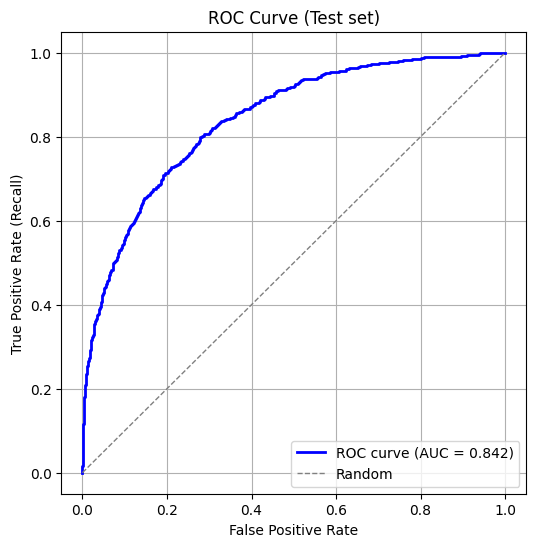

In [7]:
#AUC and ROC for model 2
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# TRAIN
y_train_probs = best_xgb.predict_proba(X_train_processed)[:, 1]
auc_train = roc_auc_score(y_train, y_train_probs)

# VALIDATION
y_val_probs = best_xgb.predict_proba(X_val_processed)[:, 1]
auc_val = roc_auc_score(y_val, y_val_probs)

# TEST
y_test_probs = best_xgb.predict_proba(X_test_processed)[:, 1]
auc_test = roc_auc_score(y_test, y_test_probs)

print(f"AUC (Train): {auc_train:.3f}")
print(f"AUC (Validation): {auc_val:.3f}")
print(f"AUC (Test): {auc_test:.3f}")



# Test set ROC
y_test_probs = best_xgb.predict_proba(X_test_processed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve (Test set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [8]:
#AUPRC for model 2
from sklearn.metrics import precision_recall_curve, average_precision_score

# ------------------------------
#  AUPRC CALCULATION
# ------------------------------

def compute_auprc(y_true, y_prob):
    """Returns the AUPRC and the full precision-recall curve."""
    auprc = average_precision_score(y_true, y_prob)
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    return auprc, precision, recall, thresholds

# TRAIN
auprc_train, prec_train, rec_train, thr_train = compute_auprc(y_train, y_train_probs)

# VALIDATION
auprc_val, prec_val, rec_val, thr_val = compute_auprc(y_val, y_val_probs)

# TEST
auprc_test, prec_test, rec_test, thr_test = compute_auprc(y_test, y_test_probs)

print(f"AUPRC (Train): {auprc_train:.3f}")
print(f"AUPRC (Validation): {auprc_val:.3f}")
print(f"AUPRC (Test): {auprc_test:.3f}")


AUPRC (Train): 0.797
AUPRC (Validation): 0.574
AUPRC (Test): 0.587


In [9]:
# Code for model 3------------------------------
# 1. IMPORTS
# ------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix, make_scorer
from xgboost import XGBClassifier

# ------------------------------
# 2. LOAD DATA
# ------------------------------
df = pd.read_csv("icu_mortality_prediction_data_version_3.csv")
target = "long_icu_stay"  # 0/1

# ------------------------------
# 3. TRAIN/VAL/TEST SPLIT
# ------------------------------
X = df.drop(columns=[target])
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
print(f"Target distribution (train):\n{y_train.value_counts()}")

# ------------------------------
# 4. PIPELINE (Handle NaNs + Scaling)
# ------------------------------
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[("prep", preprocessor)])

X_train_processed = pipeline.fit_transform(X_train)
X_val_processed = pipeline.transform(X_val)
X_test_processed = pipeline.transform(X_test)

# ------------------------------
# 5. XGBOOST CLASSIFIER
# ------------------------------
# Automatic handling of class imbalance using scale_pos_weight
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    objective="binary:logistic",
    n_jobs=-1,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# ------------------------------
# 6. HYPERPARAMETER TUNING
# ------------------------------
param_grid = {
    "n_estimators": [100, 200, 300,400,500],
    "max_depth": [3, 5, 6],
    "learning_rate": [0.05, 0.1, 0.15],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 0.9],
    "gamma": [0, 0.1]
}

# Use F1 score for hyperparameter optimization (positive class = 1)
f1_scorer = make_scorer(f1_score, pos_label=1)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,  # reduce for speed
    cv=3,
    scoring=f1_scorer,  # <-- F1 instead of ROC-AUC
    verbose=1,
    random_state=42
)

random_search.fit(X_train_processed, y_train)
best_xgb = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

# ------------------------------
# 7. FIT BEST MODEL
# ------------------------------
best_xgb.fit(X_train_processed, y_train)

# ------------------------------
# 8. THRESHOLD TUNING (Validation)
# ------------------------------
y_val_probs = best_xgb.predict_proba(X_val_processed)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)
f1_scores = []

for t in thresholds:
    y_val_pred = (y_val_probs >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_val_pred))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
print(f"Best threshold (validation F1): {best_threshold:.2f}, Max F1: {best_f1:.4f}")

# ------------------------------
# 9. EVALUATION FUNCTION
# ------------------------------
def evaluate_model(model, X, y, threshold):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)
    print("F1-score:", f1_score(y, preds))
    print("Accuracy:", (preds == y).mean())
    print(classification_report(y, preds))
    print("Confusion Matrix:\n", confusion_matrix(y, preds))

# ------------------------------
# 10. FINAL EVALUATION
# ------------------------------
print("TRAIN PERFORMANCE")
evaluate_model(best_xgb, X_train_processed, y_train, best_threshold)

print("VALIDATION PERFORMANCE")
evaluate_model(best_xgb, X_val_processed, y_val, best_threshold)

print("TEST PERFORMANCE")
evaluate_model(best_xgb, X_test_processed, y_test, best_threshold)


Train: (25437, 183), Validation: (5451, 183), Test: (5451, 183)
Target distribution (train):
long_icu_stay
0    21213
1     4224
Name: count, dtype: int64
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV score: 0.5297221086174358
Best threshold (validation F1): 0.64, Max F1: 0.5503
TRAIN PERFORMANCE
F1-score: 0.675576344804544
Accuracy: 0.8854817785116169
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     21213
           1       0.64      0.72      0.68      4224

    accuracy                           0.89     25437
   macro avg       0.79      0.82      0.80     25437
weighted avg       0.89      0.89      0.89     25437

Confusion Matrix:
 [[19491  1722]
 [ 1191  3033]]
VALIDATION PERFORMANCE
F1-score: 0.5503426462836057
Accuracy: 0.8435149513850669
              precision    reca

AUC (Train): 0.922
AUC (Validation): 0.839
AUC (Test): 0.835


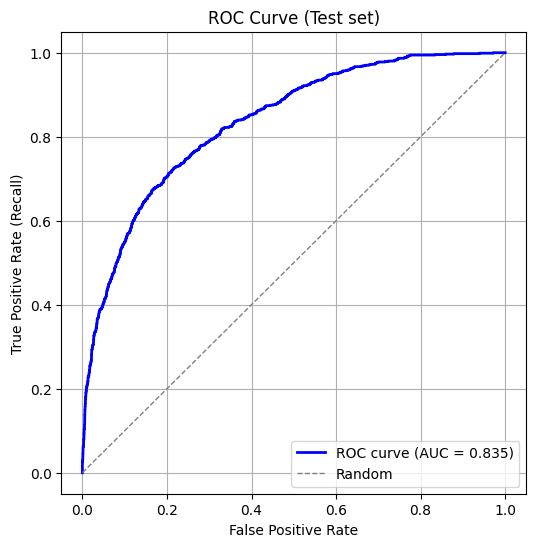

In [10]:
#ROC and AUC for model 3
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# TRAIN
y_train_probs = best_xgb.predict_proba(X_train_processed)[:, 1]
auc_train = roc_auc_score(y_train, y_train_probs)

# VALIDATION
y_val_probs = best_xgb.predict_proba(X_val_processed)[:, 1]
auc_val = roc_auc_score(y_val, y_val_probs)

# TEST
y_test_probs = best_xgb.predict_proba(X_test_processed)[:, 1]
auc_test = roc_auc_score(y_test, y_test_probs)

print(f"AUC (Train): {auc_train:.3f}")
print(f"AUC (Validation): {auc_val:.3f}")
print(f"AUC (Test): {auc_test:.3f}")



# Test set ROC
y_test_probs = best_xgb.predict_proba(X_test_processed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve (Test set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [11]:
#AUPRC for model 3
from sklearn.metrics import precision_recall_curve, average_precision_score

# ------------------------------
#  AUPRC CALCULATION
# ------------------------------

def compute_auprc(y_true, y_prob):
    """Returns the AUPRC and the full precision-recall curve."""
    auprc = average_precision_score(y_true, y_prob)
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    return auprc, precision, recall, thresholds

# TRAIN
auprc_train, prec_train, rec_train, thr_train = compute_auprc(y_train, y_train_probs)

# VALIDATION
auprc_val, prec_val, rec_val, thr_val = compute_auprc(y_val, y_val_probs)

# TEST
auprc_test, prec_test, rec_test, thr_test = compute_auprc(y_test, y_test_probs)

print(f"AUPRC (Train): {auprc_train:.3f}")
print(f"AUPRC (Validation): {auprc_val:.3f}")
print(f"AUPRC (Test): {auprc_test:.3f}")



AUPRC (Train): 0.745
AUPRC (Validation): 0.566
AUPRC (Test): 0.562
